In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

DEVICE = torch.device("cpu")
torch.manual_seed(42)
np.random.seed(42)

# =============================================================
# 1. NONLINEAR FORWARD MODEL
# =============================================================
SIGMA_TRUE = 1e-4

def forward_nonlinear(m, e):
    return m**2 + e

def exact_sigma_m(m, sigma_d):
    return sigma_d / (2 * m)

print("="*60)
print("NONLINEAR MODEL: d = m^2 + e")
print("Analytical: sigma_m = sigma_d / (2m)")
print("="*60)

# =============================================================
# 2. DATA GENERATION
# =============================================================
SIZE = 100_000

# Avoid m close to zero (important!)
m_data = np.random.uniform(0.2, 1.0, SIZE)
e_data = np.random.uniform(0, 1, SIZE)
noise  = np.random.normal(0, SIGMA_TRUE, SIZE)

d_data = forward_nonlinear(m_data, e_data) + noise

data = torch.tensor(
    np.stack([m_data, e_data, d_data], axis=1),
    dtype=torch.float32
)

# =============================================================
# 3. UTILITIES
# =============================================================
def sample_xt(x0, x1, t, sigma=0.01):
    t = t.view(-1, 1)
    return t * x1 + (1 - t) * x0 + sigma * torch.randn_like(x0)

def vector_field(x0, x1):
    return x1 - x0

@torch.no_grad()
def ode_sample_na(model, d_cond, sd_cond, e_cond, n_samples=200, steps=50):
    model.eval()
    # Ensure x is float32, which is default for torch.rand()
    x = torch.rand(n_samples, 1)
    dt = 1.0 / steps

    for i in range(steps):
        # Ensure t_val is float32, which is default for torch.full()
        t_val = torch.full((n_samples, 1), i * dt)
        inp = torch.cat([x, d_cond.expand(n_samples,1),
                         sd_cond.expand(n_samples,1),
                         e_cond.expand(n_samples,1),
                         t_val], dim=1)
        x = x + dt * model(inp)
    return x

# =============================================================
# 4. NA-CFM MODEL
# =============================================================
class NoiseAwareCFM(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 128), nn.SELU(),
            nn.Linear(128,128), nn.SELU(),
            nn.Linear(128,128), nn.SELU(),
            nn.Linear(128,1)
        )
    def forward(self,x): return self.net(x)

model = NoiseAwareCFM()
opt = optim.Adam(model.parameters(), lr=1e-3)

SIGMA_D_MIN = 1e-4
SIGMA_D_MAX = 1e-1

# =============================================================
# 5. TRAIN NA-CFM
# =============================================================
print("\nTraining NA-CFM...")

for step in tqdm(range(10000)):
    idx = torch.randint(0, len(data), (512,))
    batch = data[idx]

    x1 = batch[:,0:1]
    e  = batch[:,1:2]
    d  = batch[:,2:3]

    log_sd = torch.FloatTensor(512,1).uniform_(
        np.log(SIGMA_D_MIN), np.log(SIGMA_D_MAX)
    )
    sigma_d = torch.exp(log_sd)

    d_noisy = d + sigma_d * torch.randn_like(d)

    x0 = torch.rand_like(x1)
    t  = torch.rand(512)

    xt = sample_xt(x0,x1,t)
    ut = vector_field(x0,x1)

    inp = torch.cat([xt, d_noisy, sigma_d, e, t[:,None]], dim=1)

    loss = ((model(inp)-ut)**2).mean()

    opt.zero_grad()
    loss.backward()
    opt.step()

print("Training done.")

# =============================================================
# 6. VALIDATION
# =============================================================
print("\nValidation...")

test_m_values = [0.5, 0.8]
sigma_d_values = np.logspace(-3, -1, 6)

results = {}

for m_target in test_m_values:
    # find closest point
    idx = torch.argmin(torch.abs(data[:,0]-m_target))
    m_true = float(data[idx,0])
    e_val  = float(data[idx,1])
    d_val  = float(data[idx,2])

    # Explicitly cast to torch.float32
    d_t = torch.tensor([[d_val]], dtype=torch.float32)
    e_t = torch.tensor([[e_val]], dtype=torch.float32)

    pred_sigmas = []
    gt_sigmas   = []

    for sd in sigma_d_values:
        # Explicitly cast to torch.float32
        sd_t = torch.tensor([[sd]], dtype=torch.float32)

        samples = ode_sample_na(model, d_t, sd_t, e_t, n_samples=500)
        sigma_pred = float(samples.std())

        sigma_gt = exact_sigma_m(m_true, sd)

        pred_sigmas.append(sigma_pred)
        gt_sigmas.append(sigma_gt)

    results[m_true] = (pred_sigmas, gt_sigmas)

# # =============================================================
# # 7. PLOT
# # =============================================================
# plt.figure(figsize=(8,6))

# for m_val, (pred, gt) in results.items():
#     plt.plot(sigma_d_values, gt, '--', label=f"GT m={m_val:.2f}")
#     plt.plot(sigma_d_values, pred, 'o-', label=f"Model m={m_val:.2f}")

# plt.xscale("log")
# plt.yscale("log")
# plt.xlabel("sigma_d")
# plt.ylabel("sigma_m")
# plt.title("Nonlinear UQ Validation: Model vs Analytical")
# plt.legend()
# plt.grid(True)
# plt.show()

NONLINEAR MODEL: d = m^2 + e
Analytical: sigma_m = sigma_d / (2m)

Training NA-CFM...


100%|██████████| 10000/10000 [00:39<00:00, 255.07it/s]


Training done.

Validation...


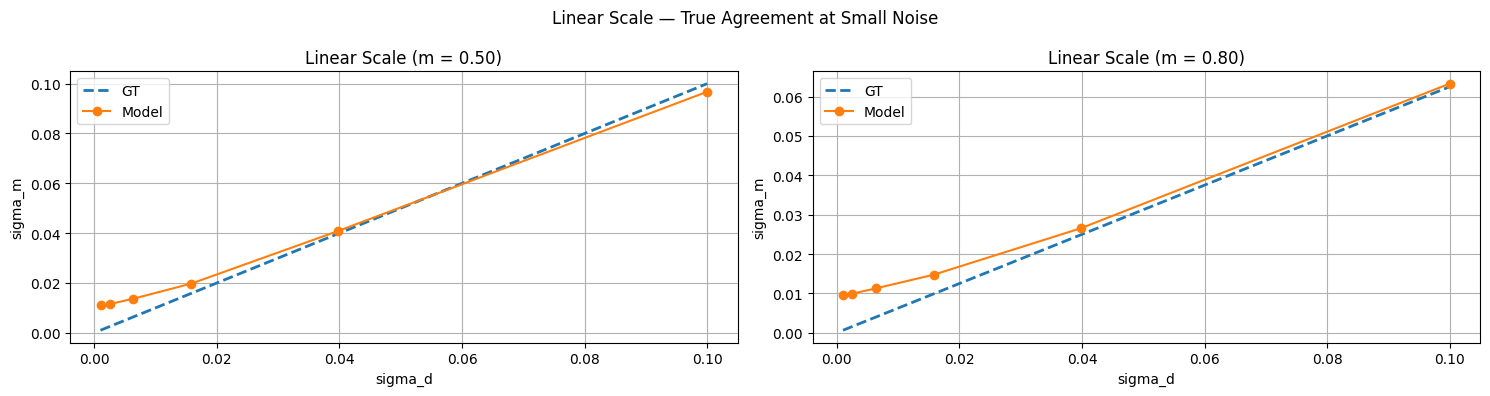

In [2]:
# =============================================================
# 8. LINEAR SCALE PLOT (NO EXAGGERATION)
# =============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for i, (m_val, (pred, gt)) in enumerate(results.items()):
    ax = axes[i]

    ax.plot(sigma_d_values, gt, '--', linewidth=2, label="GT")
    ax.plot(sigma_d_values, pred, 'o-', label="Model")

    # 🔥 Linear scale
    ax.set_title(f"Linear Scale (m = {m_val:.2f})")
    ax.set_xlabel("sigma_d")
    ax.set_ylabel("sigma_m")
    ax.grid(True)
    ax.legend()

plt.suptitle("Linear Scale — True Agreement at Small Noise")
plt.tight_layout()
plt.show()